# AAA_VLM_EVAL

Inference для validation split через дообученный LoRA-чекпоинт Qwen3-VL. Ноутбук берёт `valid_with_params.csv`, извлекает нужные изображения, загружает базовую `Qwen/Qwen3-VL-4B-Instruct` + последний `ckpt-step-*` из attached dataset и сохраняет JSON с ответами в `/kaggle/working`.

In [1]:
# Runtime dependencies. Keep imports that need these packages in later cells.
import subprocess
import sys

PACKAGES = [
    "transformers>=4.57.0,<5.0.0",
    "accelerate>=1.12.0,<1.14.0",
    "peft>=0.17.0,<0.19.0",
    "bitsandbytes>=0.48.0,<0.49.0",
    "safetensors>=0.6.0",
    "huggingface_hub>=0.34.0,<1.0.0",
    "qwen-vl-utils>=0.0.14,<0.1.0",
]

print("Installing/updating inference dependencies...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *PACKAGES])
print("Dependency install complete")


Installing/updating inference dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 55.7 MB/s eta 0:00:00
Dependency install complete


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import gc
import json
import math
import os
import re
import shutil
import tarfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image

INPUT_ROOT = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")
TEMP_ROOT = Path("/kaggle/temp")
WORKING_ROOT.mkdir(parents=True, exist_ok=True)
TEMP_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
MIN_PIXELS = 128 * 28 * 28
MAX_PIXELS = 512 * 28 * 28
MAX_NEW_TOKENS = 384
GENERATION_KWARGS = {
    "max_new_tokens": MAX_NEW_TOKENS,
    "do_sample": True,
    "temperature": 0.3,
    "top_p": 0.7,
    "repetition_penalty": 1.05,
}

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUDA_MODULE_LOADING", "LAZY")
os.environ.setdefault("TORCH_EXTENSIONS_DIR", str(TEMP_ROOT / "torch_extensions"))
Path(os.environ["TORCH_EXTENSIONS_DIR"]).mkdir(parents=True, exist_ok=True)
try:
    Path("/root/.cache/torch/kernels").mkdir(parents=True, exist_ok=True)
except Exception as exc:
    print("kernel cache dir warning:", repr(exc))

if not torch.cuda.is_available():
    raise RuntimeError("CUDA недоступна: этот eval нужно запускать на GPU")

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

device_count = torch.cuda.device_count()
print("CUDA available:", torch.cuda.is_available())
print("CUDA device_count:", device_count)
for i in range(device_count):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name}, memory_gb={props.total_memory / 1024**3:.2f}")

print("/kaggle/input top-level:")
for p in sorted(INPUT_ROOT.iterdir()):
    print(" -", p)


CUDA available: True
CUDA device_count: 2
GPU 0: Tesla T4, memory_gb=14.56
GPU 1: Tesla T4, memory_gb=14.56
/kaggle/input top-level:
 - /kaggle/input/datasets


In [3]:
def step_from_ckpt(path: Path) -> int:
    m = re.search(r"ckpt-step-(\d+)$", path.name)
    return int(m.group(1)) if m else -1


def checkpoint_is_complete(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / "adapter_model.safetensors").exists()
        and (path / "adapter_config.json").exists()
    )


def find_valid_csv() -> Path:
    hits = sorted(INPUT_ROOT.rglob("valid_with_params.csv"))
    if not hits:
        raise FileNotFoundError("Не найден valid_with_params.csv в /kaggle/input")
    return hits[0]


def find_latest_checkpoint() -> Path:
    hits = [p for p in INPUT_ROOT.rglob("ckpt-step-*") if checkpoint_is_complete(p)]
    if not hits:
        raise FileNotFoundError("Не найден полный ckpt-step-* с adapter_model.safetensors и adapter_config.json")
    return max(hits, key=lambda p: step_from_ckpt(p))


def find_image_archive() -> Path:
    exact = [p for p in INPUT_ROOT.rglob("AAA_1image_dataset_images") if p.is_file()]
    if exact:
        return exact[0]

    likely = []
    for p in INPUT_ROOT.rglob("*"):
        if not p.is_file():
            continue
        name = p.name.lower()
        if "image" in name or "img" in name:
            if p.suffix.lower() in {".tar", ".tgz", ".gz", ".zip", ""}:
                likely.append(p)
    for p in sorted(likely, key=lambda x: x.stat().st_size, reverse=True):
        try:
            if tarfile.is_tarfile(p):
                return p
        except Exception:
            pass
    raise FileNotFoundError("Не найден tar-архив с изображениями")

VALID_CSV = find_valid_csv()
CHECKPOINT_DIR = find_latest_checkpoint()
CHECKPOINT_STEP = step_from_ckpt(CHECKPOINT_DIR)
IMAGE_ARCHIVE = find_image_archive()

OUTPUT_JSON = WORKING_ROOT / f"val_ckpt_step_{CHECKPOINT_STEP}.json"
PARTIAL_JSON = WORKING_ROOT / f"val_ckpt_step_{CHECKPOINT_STEP}.partial.json"
SUMMARY_JSON = WORKING_ROOT / f"val_ckpt_step_{CHECKPOINT_STEP}.summary.json"

print("VALID_CSV:", VALID_CSV)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("CHECKPOINT_STEP:", CHECKPOINT_STEP)
print("IMAGE_ARCHIVE:", IMAGE_ARCHIVE, f"{IMAGE_ARCHIVE.stat().st_size / 1024**3:.2f} GB")
print("OUTPUT_JSON:", OUTPUT_JSON)

val_df = pd.read_csv(VALID_CSV)
print("valid shape:", val_df.shape)
print("valid columns:", list(val_df.columns))

required_cols = {"item_id", "image_id", "title", "category_name", "params"}
missing_cols = sorted(required_cols - set(val_df.columns))
if missing_cols:
    raise ValueError(f"В valid не хватает колонок: {missing_cols}")

VAL_IMAGE_DIR = TEMP_ROOT / "aaa_val_images"
VAL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

wanted_image_ids = set(pd.to_numeric(val_df["image_id"], errors="raise").astype("int64"))
existing_image_ids = {int(p.stem) for p in VAL_IMAGE_DIR.glob("*.jpg") if p.stem.isdigit()}
missing_to_extract = wanted_image_ids - existing_image_ids
print("нужно изображений:", len(wanted_image_ids), "уже извлечено:", len(existing_image_ids & wanted_image_ids), "осталось:", len(missing_to_extract))

if missing_to_extract:
    t0 = time.time()
    extracted = 0
    scanned_files = 0
    with tarfile.open(IMAGE_ARCHIVE, "r:*") as tar:
        for member in tar:
            if not member.isfile():
                continue
            scanned_files += 1
            stem = Path(member.name).stem
            if not stem.isdigit():
                continue
            image_id = int(stem)
            if image_id not in missing_to_extract:
                continue
            src = tar.extractfile(member)
            if src is None:
                continue
            out_path = VAL_IMAGE_DIR / f"{image_id}.jpg"
            with src, open(out_path, "wb") as dst:
                shutil.copyfileobj(src, dst)
            extracted += 1
            if extracted % 20 == 0:
                print(f"извлечено {extracted}/{len(missing_to_extract)}")
            if extracted == len(missing_to_extract):
                break
    print(f"извлечено {extracted} изображений за {time.time() - t0:.1f} сек.; просмотрено файлов в tar: {scanned_files}")

image_path_by_id = {int(p.stem): p for p in VAL_IMAGE_DIR.glob("*.jpg") if p.stem.isdigit()}
missing_after = sorted(wanted_image_ids - set(image_path_by_id))
print("изображений в индексе для valid:", len(set(image_path_by_id) & wanted_image_ids))
print("missing_after:", missing_after[:10], "count=", len(missing_after))
if missing_after:
    raise FileNotFoundError(f"Не найдены изображения для {len(missing_after)} valid rows")

sample_id = int(val_df.iloc[0]["image_id"])
with Image.open(image_path_by_id[sample_id]) as img:
    print("sample image:", image_path_by_id[sample_id], img.size, img.mode)


VALID_CSV: /kaggle/input/datasets/kotshubin/aaa-1image-dataset-30k/valid_with_params.csv
CHECKPOINT_DIR: /kaggle/input/datasets/kotshubin/aaa-vlm-sft-checkpoints/checkpoints/ckpt-step-3000
CHECKPOINT_STEP: 3000
IMAGE_ARCHIVE: /kaggle/input/datasets/kotshubin/aaa-1image-dataset-images/AAA_1image_dataset_images 10.73 GB
OUTPUT_JSON: /kaggle/working/val_ckpt_step_3000.json
valid shape: (100, 20)
valid columns: ['item_id', 'image_id', 'title', 'description', 'category_id', 'category_name', 'microcat_id', 'microcat_name', 'itemstatus_id', 'price', 'imagescount', 'isshop', 'iscompany', 'hasbusinessprofile', 'reputationscore', 'starttime', 'quality_score', 'in_filtered_dataset', 'split', 'params']
нужно изображений: 100 уже извлечено: 0 осталось: 100
извлечено 20/100
извлечено 40/100
извлечено 60/100
извлечено 80/100
извлечено 100/100
извлечено 100 изображений за 113.5 сек.; просмотрено файлов в tar: 258574
изображений в индексе для valid: 100
missing_after: [] count= 0
sample image: /kaggle/

In [4]:
PROMPT_TEMPLATE = 'Ты пишешь товарное описание для объявления на Авито на русском языке.\n\n# Главный принцип\nЭто описание товара для покупателя, а не подпись к фотографии и не рекламный текст с догадками. Нужно ясно описать, что продаётся, в каком состоянии товар и какие характеристики указаны во входных данных.\n\nКаждое утверждение должно опираться на один из источников:\n1. `title`;\n2. `category_name`;\n3. `params`;\n4. товарно-значимая деталь самого товара, которую прямо видно на фотографии.\n\nЕсли утверждение нельзя проверить по этим данным — не пиши его. Лучше коротко перечислить подтверждённые свойства, чем добавлять красивую неподтверждённую фразу.\n\n# Что тебе дано\n1. **Фотография товара** (одно изображение).\n2. **Заголовок объявления** (`title`).\n3. **Категория** (`category_name`).\n4. **Характеристики** (`params`) — JSON-словарь со структурированными свойствами. Ключи не нормализованы: могут быть в форматах `с_подчёркиваниями`, `camelCase` или `с пробелами`. Используй их по смыслу.\n\n# Что нужно написать\nОдин абзац с товарным описанием:\n- начни с предмета продажи: тип товара, бренд, модель, версия, порода или категория — по `title` и `params`;\n- укажи состояние и 2–4 ключевые характеристики из `params`, если они есть;\n- используй фото только для важных свойств самого товара: цвет, материал, комплектность, заметные дефекты, общий внешний вид товара;\n- если фото даёт только фон/сцену/ракурс, игнорируй эти детали.\n\n# Как использовать фото\nФото помогает уточнить свойства товара, но не должно превращать ответ в описание картинки.\n\nИспользуй максимум 1–2 визуальных признака и только если они важны покупателю: цвет/окрас, материал, явная комплектность, явный дефект. Если визуальная деталь сомнительна или не влияет на покупку — пропусти её.\n\nПиши факт напрямую: «белый корпус», «зелёная дверь», «дымчато-серый окрас». Не ссылайся на источник факта.\n\nНельзя писать:\n- «на фото видно», «на фото виден», «видны», «указано», «указаны», «по описанию», «лежит», «стоит», «держат в руках»;\n- фон, покрывало, стол, пол, гараж, склад, руки, позу, ракурс, освещение, монитор рядом, поверхность под товаром;\n- очевидные мелочи вроде логотипа, вентиляционных решёток, складок фона, если это не ключевая характеристика товара.\n\n# Запрещённые неподтверждённые выводы\n- НЕ пиши «подходит», «подойдёт», «для дома», «для гаража», «для игр», «для установки», если это прямо не указано в `title` или `params`.\n- НЕ пиши «без повреждений», «без дефектов», «отличное внешнее состояние», «полный комплект», «оригинальный контроллер», «дверь в сборе», «без стекла», «без ручки», если это прямо не указано в `params` или `title`.\n- НЕ добавляй пустые общие фразы: «товар предназначен для использования», «подойдёт для покупки», «хороший вариант», «можно использовать по назначению».\n- Для животных НЕ пиши про здоровье, активность, характер, адаптацию, лоток, питание, прививки или готовность к переезду, если этого нет в `params` или `title`.\n- Для электроники НЕ пиши про работоспособность сверх того, что указано в `params`; если есть `состояние`, повтори его без расширения.\n- Для автозапчастей НЕ додумывай совместимость, комплектность, наличие/отсутствие стекла, ручек, креплений или историю использования, если этого нет во входных данных.\n\n# Общие запреты\n- НЕ додумывай сценарии использования, хранения, перевозки, ремонта, подарка или перепродажи.\n- НЕ приписывай товару качество, выгоду или эмоцию: «удобный», «практичный», «надёжный», «отличный вариант», «как новый», если это не подтверждено `params` или фото.\n- НЕ упоминай цену, скидки, способы оплаты, доставку, гарантии, контакты, ссылки, Telegram, WhatsApp, соцсети.\n- НЕ используй emoji, markdown-разметку, заголовки, маркированные списки.\n- НЕ повторяй `title` дословно как первую фразу.\n- НЕ пиши «Здравствуйте» / «Уважаемые покупатели».\n\n# Стиль и длина\nСтиль спокойный и естественный, как у продавца, который аккуратно перечисляет подтверждённые свойства товара. Без рекламных украшений. Не более 70 слов. Если данных мало — можно написать одно короткое предложение. Не добавляй финальную фразу ради красоты.\n\n# Формат вывода\nВыдай только текст описания. Без префикса «Описание:», без пояснений и рассуждений.\n\n# Данные товара\n**title:** {title}\n**category_name:** {category_name}\n**params:** {params}\n\nНапиши описание.'

print("prompt chars:", len(PROMPT_TEMPLATE))
print(PROMPT_TEMPLATE[:500], "...")


prompt chars: 4272
Ты пишешь товарное описание для объявления на Авито на русском языке.

# Главный принцип
Это описание товара для покупателя, а не подпись к фотографии и не рекламный текст с догадками. Нужно ясно описать, что продаётся, в каком состоянии товар и какие характеристики указаны во входных данных.

Каждое утверждение должно опираться на один из источников:
1. `title`;
2. `category_name`;
3. `params`;
4. товарно-значимая деталь самого товара, которую прямо видно на фотографии.

Если утверждение нельзя ...


In [5]:
from fnmatch import fnmatch

MODEL_CACHE_ROOT = TEMP_ROOT / "hf_cache"
MODEL_LOCAL_DIR = TEMP_ROOT / "qwen3_vl_4b_instruct"
MODEL_DOWNLOAD_STATUS = WORKING_ROOT / "model_download_status.json"
MODEL_CACHE_INFO_PATH = WORKING_ROOT / "model_cache_info.json"
MODEL_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

hf_env = {
    "HF_HOME": str(MODEL_CACHE_ROOT),
    "HF_HUB_CACHE": str(MODEL_CACHE_ROOT / "hub"),
    "TRANSFORMERS_CACHE": str(MODEL_CACHE_ROOT / "transformers"),
    "HF_HUB_DISABLE_XET": "1",
    "HF_HUB_ETAG_TIMEOUT": "30",
    "HF_HUB_DOWNLOAD_TIMEOUT": "600",
}
for key, value in hf_env.items():
    os.environ[key] = value
    print(f"HF env {key}={value}", flush=True)

from huggingface_hub import hf_hub_download, model_info

MODEL_ALLOW_PATTERNS = [
    "*.safetensors",
    "*.safetensors.index.json",
    "*.json",
    "*.txt",
    "*.model",
    "*.jinja",
    "image_processing*.py",
    "video_processing*.py",
    "processing*.py",
    "tokenization*.py",
    "configuration*.py",
    "modeling*.py",
]
MODEL_SKIP_PATTERNS = [
    "*.md",
    "*.gguf",
    "*.onnx",
    "*.tflite",
    "*.msgpack",
    "optimizer*",
    "training_args*",
]
MODEL_FILE_TIMEOUT_SEC = 900


def model_cache_ready(path: Path) -> bool:
    has_config = (path / "config.json").exists()
    has_weights = any(path.rglob("*.safetensors"))
    tokenizer_markers = [
        "tokenizer_config.json",
        "tokenizer.json",
        "vocab.json",
        "merges.txt",
        "tokenizer.model",
    ]
    processor_markers = ["preprocessor_config.json", "processor_config.json"]
    has_tokenizer = any((path / name).exists() for name in tokenizer_markers)
    has_processor = any((path / name).exists() for name in processor_markers)
    return has_config and has_weights and has_tokenizer and has_processor


def model_cache_score(path: Path) -> tuple[int, int]:
    if not path.is_dir():
        return (0, 0)
    score = 0
    if (path / "config.json").exists():
        score += 1
    if any(path.rglob("*.safetensors")):
        score += 1
    if any((path / name).exists() for name in ["tokenizer_config.json", "tokenizer.json", "vocab.json", "merges.txt", "tokenizer.model"]):
        score += 1
    if any((path / name).exists() for name in ["preprocessor_config.json", "processor_config.json"]):
        score += 1
    total_bytes = sum(p.stat().st_size for p in path.rglob("*") if p.is_file())
    return (score, total_bytes)


def find_mounted_base_model() -> Path | None:
    candidates = []
    for config_path in INPUT_ROOT.rglob("config.json"):
        root = config_path.parent
        if root == CHECKPOINT_DIR:
            continue
        if "aaa-vlm-sft-checkpoints" in str(root):
            continue
        if model_cache_ready(root):
            candidates.append(root)
    if not candidates:
        return None
    return max(candidates, key=model_cache_score)


def should_download_model_file(name: str) -> bool:
    if any(fnmatch(name, pattern) for pattern in MODEL_SKIP_PATTERNS):
        return False
    return any(fnmatch(name, pattern) for pattern in MODEL_ALLOW_PATTERNS)


def write_download_status(payload: dict) -> None:
    tmp_path = MODEL_DOWNLOAD_STATUS.with_suffix(MODEL_DOWNLOAD_STATUS.suffix + ".tmp")
    tmp_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    tmp_path.replace(MODEL_DOWNLOAD_STATUS)


def download_one_file_with_timeout(repo_id: str, filename: str, expected_size: int | None, index: int, total: int) -> Path:
    import signal

    class ModelFileTimeout(TimeoutError):
        pass

    def _handler(signum, frame):
        raise ModelFileTimeout(f"timeout while downloading {filename} after {MODEL_FILE_TIMEOUT_SEC}s")

    started = time.time()
    print(
        f"DOWNLOAD_START {index}/{total} file={filename} expected_mb={(expected_size or 0) / 1024**2:.1f}",
        flush=True,
    )
    write_download_status({
        "status": "downloading",
        "repo_id": repo_id,
        "file": filename,
        "index": index,
        "total": total,
        "expected_size": expected_size,
        "started_at_unix": started,
    })

    previous_handler = signal.signal(signal.SIGALRM, _handler)
    signal.alarm(MODEL_FILE_TIMEOUT_SEC)
    try:
        local_path = hf_hub_download(
            repo_id=repo_id,
            filename=filename,
            local_dir=str(MODEL_LOCAL_DIR),
            cache_dir=str(MODEL_CACHE_ROOT / "hub"),
            local_files_only=False,
        )
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, previous_handler)

    local_path = Path(local_path)
    elapsed = time.time() - started
    actual_size = local_path.stat().st_size if local_path.exists() else None
    print(
        f"DOWNLOAD_DONE {index}/{total} file={filename} actual_mb={(actual_size or 0) / 1024**2:.1f} elapsed_sec={elapsed:.1f}",
        flush=True,
    )
    write_download_status({
        "status": "downloaded",
        "repo_id": repo_id,
        "file": filename,
        "index": index,
        "total": total,
        "expected_size": expected_size,
        "actual_size": actual_size,
        "elapsed_sec": round(elapsed, 1),
    })
    return local_path


def cache_model_from_hf(repo_id: str) -> dict:
    print("MODEL_SOURCE: hf_download", repo_id, flush=True)
    import signal

    class ModelInfoTimeout(TimeoutError):
        pass

    def _info_timeout_handler(signum, frame):
        raise ModelInfoTimeout(f"timeout while reading model_info for {repo_id}")

    info_t0 = time.time()
    print("MODEL_INFO_START", repo_id, flush=True)
    previous_handler = signal.signal(signal.SIGALRM, _info_timeout_handler)
    signal.alarm(120)
    try:
        info = model_info(repo_id=repo_id, files_metadata=True)
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, previous_handler)
    print("MODEL_INFO_DONE elapsed_sec=", round(time.time() - info_t0, 1), "siblings=", len(info.siblings), flush=True)

    files = []
    for sibling in info.siblings:
        name = sibling.rfilename
        if should_download_model_file(name):
            files.append((name, getattr(sibling, "size", None)))
    files = sorted(files, key=lambda x: (0 if x[0].endswith(".json") or x[0].endswith(".txt") else 1, x[0]))

    if not files:
        raise FileNotFoundError(f"Не нашёл файлов модели для скачивания в {repo_id}")

    print("MODEL_DOWNLOAD_PLAN files=", len(files), "total_gb=", round(sum(size or 0 for _, size in files) / 1024**3, 3), flush=True)
    for i, (name, size) in enumerate(files, start=1):
        target = MODEL_LOCAL_DIR / name
        if target.exists() and (size is None or target.stat().st_size == size):
            print(f"DOWNLOAD_SKIP {i}/{len(files)} file={name} size_mb={target.stat().st_size / 1024**2:.1f}", flush=True)
            continue
        download_one_file_with_timeout(repo_id, name, size, i, len(files))

    if not model_cache_ready(MODEL_LOCAL_DIR):
        present = sorted(str(p.relative_to(MODEL_LOCAL_DIR)) for p in MODEL_LOCAL_DIR.rglob("*") if p.is_file())[:100]
        raise FileNotFoundError(f"Model cache неполный после HF download: {MODEL_LOCAL_DIR}; first_files={present}")

    return {"model_source": "hf_download", "model_dir": str(MODEL_LOCAL_DIR)}


t0 = time.time()
mounted_model_dir = find_mounted_base_model()
if mounted_model_dir is not None:
    MODEL_LOCAL_DIR = mounted_model_dir
    source_info = {"model_source": "mounted_input", "model_dir": str(MODEL_LOCAL_DIR)}
    print("MODEL_SOURCE: mounted_input", MODEL_LOCAL_DIR, flush=True)
elif model_cache_ready(MODEL_LOCAL_DIR):
    source_info = {"model_source": "temp_cache_existing", "model_dir": str(MODEL_LOCAL_DIR)}
    print("MODEL_SOURCE: temp_cache_existing", MODEL_LOCAL_DIR, flush=True)
else:
    source_info = cache_model_from_hf(MODEL_ID)

files = [p for p in MODEL_LOCAL_DIR.rglob("*") if p.is_file()]
safetensors = [p for p in files if p.suffix == ".safetensors"]
cache_info = {
    "model_id": MODEL_ID,
    "model_local_dir": str(MODEL_LOCAL_DIR),
    "model_source": source_info["model_source"],
    "files_count": len(files),
    "safetensors_count": len(safetensors),
    "total_gb": round(sum(p.stat().st_size for p in files) / 1024**3, 3),
    "elapsed_sec": round(time.time() - t0, 1),
    "checks": {
        "config_json": (MODEL_LOCAL_DIR / "config.json").exists(),
        "has_safetensors": bool(safetensors),
        "tokenizer_config_json": (MODEL_LOCAL_DIR / "tokenizer_config.json").exists(),
        "preprocessor_config_json": (MODEL_LOCAL_DIR / "preprocessor_config.json").exists(),
        "processor_config_json": (MODEL_LOCAL_DIR / "processor_config.json").exists(),
    },
}
MODEL_CACHE_INFO_PATH.write_text(json.dumps(cache_info, ensure_ascii=False, indent=2), encoding="utf-8")
print("Model cache ready:")
print(json.dumps(cache_info, ensure_ascii=False, indent=2), flush=True)
if not model_cache_ready(MODEL_LOCAL_DIR):
    raise FileNotFoundError(f"Model cache неполный: {MODEL_LOCAL_DIR}")


HF env HF_HOME=/kaggle/temp/hf_cache
HF env HF_HUB_CACHE=/kaggle/temp/hf_cache/hub
HF env TRANSFORMERS_CACHE=/kaggle/temp/hf_cache/transformers
HF env HF_HUB_DISABLE_XET=1
HF env HF_HUB_ETAG_TIMEOUT=30
HF env HF_HUB_DOWNLOAD_TIMEOUT=600
MODEL_SOURCE: hf_download Qwen/Qwen3-VL-4B-Instruct
MODEL_INFO_START Qwen/Qwen3-VL-4B-Instruct
MODEL_INFO_DONE elapsed_sec= 0.1 siblings= 14
MODEL_DOWNLOAD_PLAN files= 12 total_gb= 8.277
DOWNLOAD_START 1/12 file=chat_template.json expected_mb=0.0


chat_template.json: 0.00B [00:00, ?B/s]

DOWNLOAD_DONE 1/12 file=chat_template.json actual_mb=0.0 elapsed_sec=0.1
DOWNLOAD_START 2/12 file=config.json expected_mb=0.0


config.json: 0.00B [00:00, ?B/s]

DOWNLOAD_DONE 2/12 file=config.json actual_mb=0.0 elapsed_sec=0.1
DOWNLOAD_START 3/12 file=generation_config.json expected_mb=0.0


...

DOWNLOAD_DONE 10/12 file=vocab.json actual_mb=2.6 elapsed_sec=0.1
DOWNLOAD_START 11/12 file=model-00001-of-00002.safetensors expected_mb=4737.1


model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

DOWNLOAD_DONE 11/12 file=model-00001-of-00002.safetensors actual_mb=4737.1 elapsed_sec=67.0
DOWNLOAD_START 12/12 file=model-00002-of-00002.safetensors expected_mb=3727.4


model-00002-of-00002.safetensors:   0%|          | 0.00/3.91G [00:00<?, ?B/s]

DOWNLOAD_DONE 12/12 file=model-00002-of-00002.safetensors actual_mb=3727.4 elapsed_sec=24.5
Model cache ready:
{
  "model_id": "Qwen/Qwen3-VL-4B-Instruct",
  "model_local_dir": "/kaggle/temp/qwen3_vl_4b_instruct",
  "model_source": "hf_download",
  "files_count": 25,
  "safetensors_count": 2,
  "total_gb": 8.277,
  "elapsed_sec": 92.9,
  "checks": {
    "config_json": true,
    "has_safetensors": true,
    "tokenizer_config_json": true,
    "preprocessor_config_json": true,
    "processor_config_json": false
  }
}


In [6]:
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig
from peft import PeftModel

try:
    from transformers import Qwen3VLForConditionalGeneration
except Exception:
    Qwen3VLForConditionalGeneration = None


def get_model_class():
    if Qwen3VLForConditionalGeneration is not None:
        return Qwen3VLForConditionalGeneration, "Qwen3VLForConditionalGeneration"
    return AutoModelForImageTextToText, "AutoModelForImageTextToText"

model_cls, model_cls_name = get_model_class()
print("model class:", model_cls_name)
print("loading processor...")
t0 = time.time()
processor = AutoProcessor.from_pretrained(
    str(MODEL_LOCAL_DIR),
    trust_remote_code=True,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
    local_files_only=True,
)
tokenizer = getattr(processor, "tokenizer", None)
if tokenizer is not None and tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
print("processor loaded elapsed_sec:", round(time.time() - t0, 1))

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

print("loading base model 4-bit...")
t0 = time.time()
base_model = model_cls.from_pretrained(
    str(MODEL_LOCAL_DIR),
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"": 0},
    trust_remote_code=True,
    local_files_only=True,
)
print("base model loaded elapsed_sec:", round(time.time() - t0, 1))
print("CUDA after base load allocated_gb=", round(torch.cuda.memory_allocated(0) / 1024**3, 2), "reserved_gb=", round(torch.cuda.memory_reserved(0) / 1024**3, 2))

print("loading LoRA checkpoint:", CHECKPOINT_DIR)
t0 = time.time()
model = PeftModel.from_pretrained(base_model, str(CHECKPOINT_DIR), is_trainable=False)
model.eval()
print("LoRA loaded elapsed_sec:", round(time.time() - t0, 1))
print("CUDA after LoRA allocated_gb=", round(torch.cuda.memory_allocated(0) / 1024**3, 2), "reserved_gb=", round(torch.cuda.memory_reserved(0) / 1024**3, 2))


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-06-08 06:30:48.267872: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780900248.638653      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780900248.769967      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780900250.043028      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780900250.043067      24 computation_pl

model class: Qwen3VLForConditionalGeneration
loading processor...


`torch_dtype` is deprecated! Use `dtype` instead!


processor loaded elapsed_sec: 1.0
loading base model 4-bit...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

base model loaded elapsed_sec: 17.1
CUDA after base load allocated_gb= 2.71 reserved_gb= 4.21
loading LoRA checkpoint: /kaggle/input/datasets/kotshubin/aaa-vlm-sft-checkpoints/checkpoints/ckpt-step-3000
LoRA loaded elapsed_sec: 3.2
CUDA after LoRA allocated_gb= 2.83 reserved_gb= 4.46


In [7]:
def json_safe(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if math.isnan(float(value)):
            return None
        return float(value)
    if isinstance(value, float) and math.isnan(value):
        return None
    if pd.isna(value):
        return None
    return value


def row_to_record(row: pd.Series) -> dict:
    return {col: json_safe(row[col]) for col in val_df.columns}


def write_json(path: Path, records: list[dict]) -> None:
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    tmp_path.write_text(json.dumps(records, ensure_ascii=False, indent=2), encoding="utf-8")
    tmp_path.replace(path)


def model_device() -> torch.device:
    for param in model.parameters():
        return param.device
    return torch.device("cuda:0")


@torch.inference_mode()
def generate_description(image: Image.Image, title: str, category: str, params: str) -> str:
    user_text = PROMPT_TEMPLATE.format(title=title, category_name=category, params=params)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": user_text},
            ],
        }
    ]
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model_device())

    out_ids = model.generate(**inputs, **GENERATION_KWARGS)
    gen_only = out_ids[:, inputs["input_ids"].shape[1]:]
    return processor.batch_decode(gen_only, skip_special_tokens=True)[0].strip()

records = []
print("Начинаю генерацию valid JSON:", len(val_df), "строк")
total_t0 = time.time()

for n, (idx, row) in enumerate(val_df.iterrows(), start=1):
    image_id = int(row["image_id"])
    image_path = image_path_by_id[image_id]
    record = row_to_record(row)
    record["checkpoint_step"] = CHECKPOINT_STEP
    record["checkpoint_name"] = CHECKPOINT_DIR.name
    record["model_id"] = MODEL_ID
    record["generation_kwargs"] = GENERATION_KWARGS
    record["qwen_sft_response"] = ""
    record["qwen_sft_error"] = ""
    record["qwen_sft_seconds"] = None

    try:
        with Image.open(image_path) as img:
            image = img.convert("RGB")
        t0 = time.time()
        pred = generate_description(
            image=image,
            title=str(row["title"]),
            category=str(row["category_name"]),
            params=str(row["params"]),
        )
        dt = time.time() - t0
        record["qwen_sft_response"] = pred
        record["qwen_sft_seconds"] = round(dt, 3)
        print(f"[{n:03d}/{len(val_df)}] item_id={row['item_id']} image_id={image_id} {dt:.1f}s {len(pred)} chars | {pred[:140]}", flush=True)
    except Exception as exc:
        record["qwen_sft_error"] = repr(exc)
        print(f"[{n:03d}/{len(val_df)}] ERROR item_id={row['item_id']} image_id={image_id}: {exc!r}", flush=True)
    finally:
        records.append(record)
        if n % 5 == 0 or n == len(val_df):
            write_json(PARTIAL_JSON, records)
            filled = sum(bool(r.get("qwen_sft_response")) for r in records)
            errors = sum(bool(r.get("qwen_sft_error")) for r in records)
            print("partial saved:", PARTIAL_JSON, "records:", len(records), "filled:", filled, "errors:", errors, flush=True)
        if torch.cuda.is_available() and n % 10 == 0:
            torch.cuda.empty_cache()

write_json(OUTPUT_JSON, records)
summary = {
    "model_id": MODEL_ID,
    "checkpoint_dir": str(CHECKPOINT_DIR),
    "checkpoint_step": CHECKPOINT_STEP,
    "valid_csv": str(VALID_CSV),
    "rows": len(records),
    "filled": sum(bool(r.get("qwen_sft_response")) for r in records),
    "errors": sum(bool(r.get("qwen_sft_error")) for r in records),
    "output_json": str(OUTPUT_JSON),
    "partial_json": str(PARTIAL_JSON),
    "generation_kwargs": GENERATION_KWARGS,
    "elapsed_min": round((time.time() - total_t0) / 60, 2),
}
SUMMARY_JSON.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Готово:")
print(json.dumps(summary, ensure_ascii=False, indent=2))


Начинаю генерацию valid JSON: 100 строк
[001/100] item_id=2378334500700 image_id=53318963226 65.8s 884 chars | Характеристики модели

— Цвет ремешка: Красный
— Ширина: 26mm

Общие характеритики

— Название бренда: NNNB
— Номер модели: For Garmin Fenix
[002/100] item_id=2199744251400 image_id=47771469743 7.8s 84 chars | Продам приборную панель мопеда альфа. 
В хорошем состоянии, без видимых повреждений.
[003/100] item_id=2342625000700 image_id=52247113010 61.9s 550 chars | Новый водяной насос C7; 3126 352-2139

В наличии на складе в Москве, доставка в день заказа.

ДВС, двигатель, насос, водяной, водяной насос,
[004/100] item_id=2289877750600 image_id=50857936136 61.8s 873 chars | Монтаж и производство монолитного профилированного поликарбоната от производителя за 1 день! 
Ваша задача — выбрать размеры и цвет, а наша —
[005/100] item_id=2347641000100 image_id=52451383516 62.4s 1045 chars | Новый iPhone 14 Pro 512GB

✅ Оригинальный телефон с заводской гарантией

✅ В наличии на складе в М

Sanity check: первые 3 объекта valid с ответами модели
item_id: 2378334500700 image_id: 53318963226
title: Ремешок для Garmin Quickfit 26mm, красный
category_name: Личные вещи
params: {"бренд": "NNNB", "модель": "For Garmin Fenix 5/5X", "ширина": "26mm", "цвет": "Красный", "пол": "Унисекс", "состояние": "Новый, без бирок", "материал": "Силикон", "совместимая_марка": "Гармин"}
qwen_sft_response: Характеристики модели

— Цвет ремешка: Красный
— Ширина: 26mm

Общие характеритики

— Название бренда: NNNB
— Номер модели: For Garmin Fenix 5/5X
— Происхождение: Китай
— Пол: Унисекс
— Тип товара: Ремешок для часов
— Совместимая марка: Гармин
— Тип материала: Силикон
— Единица измерения: штука/штуки
— Количество: 1
— Тип: ремешок
— Состояние: Новый, без бирок
— Тип товара: ремешок для часов
— Тип материала: силикон
— Пол: Унисекс
— Совместимая марка: Гармин
— Тип: ремешок для часов
— Тип материала: силикон
— Пол: Унисекс
— Совместимая марка: Гармин
— Тип: ремешок для часов
— Тип материала: сили

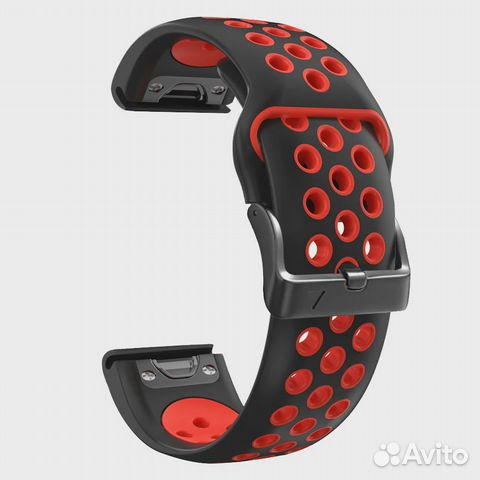

item_id: 2199744251400 image_id: 47771469743
title: Приборная панель мопед альфа
category_name: Транспорт
params: {"категория": "Транспорт", "тип": "мопед", "бренд": "альфа", "состояние": "б/у", "комплектация": "приборная панель"}
qwen_sft_response: Продам приборную панель мопеда альфа. 
В хорошем состоянии, без видимых повреждений.


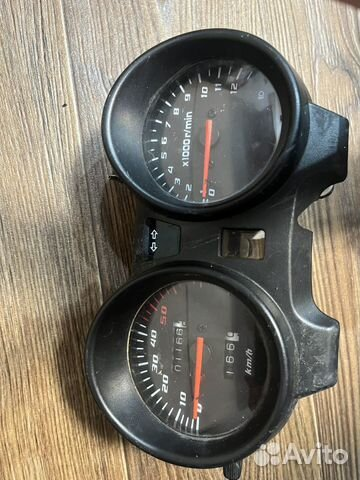

item_id: 2342625000700 image_id: 52247113010
title: Водяной насос C7; 3126 352-2139
category_name: Транспорт
params: {"бренд": "C7", "модель": "3126", "артикул": "352-2139", "состояние": "новый", "применение": "ДВС"}
qwen_sft_response: Новый водяной насос C7; 3126 352-2139

В наличии на складе в Москве, доставка в день заказа.

ДВС, двигатель, насос, водяной, водяной насос, насос водяной, насос водяной C7; 3126 352-2139, насос водяной C7; 3126 352-2139 3126, насос водяной C7; 3126 352-2139 3126 352-2139, насос водяной C7; 3126 352-2139 3126 352-2139 3126, насос водяной C7; 3126 352-2139 3126 352-2139 3126 352-2139, насос водяной C7; 3126 352-2139 3126 352-2139 3126 352-2139 3126, насос водяной C7; 3126 352-2139 3126 352-2139 3126 352-2139 3126 352-2139, насос водяной C7; 3126


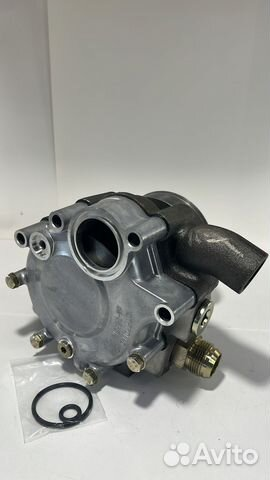

Output files:
/kaggle/working/val_ckpt_step_3000.json 418687 bytes
/kaggle/working/val_ckpt_step_3000.partial.json 418687 bytes
/kaggle/working/val_ckpt_step_3000.summary.json 628 bytes


In [8]:
from IPython.display import display

print("Sanity check: первые 3 объекта valid с ответами модели")
for rec in records[:3]:
    image_id = int(rec["image_id"])
    print("=" * 100)
    print("item_id:", rec.get("item_id"), "image_id:", image_id)
    print("title:", rec.get("title"))
    print("category_name:", rec.get("category_name"))
    print("params:", rec.get("params"))
    print("qwen_sft_response:", rec.get("qwen_sft_response"))
    if rec.get("qwen_sft_error"):
        print("qwen_sft_error:", rec.get("qwen_sft_error"))
    with Image.open(image_path_by_id[image_id]) as img:
        display(img.convert("RGB"))

print("Output files:")
for p in sorted(WORKING_ROOT.glob("val_ckpt_step_*.json")):
    print(p, p.stat().st_size, "bytes")
